In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc
import pickle
import scvi
import matplotlib.pyplot as plt

from cellina import CellinaModel
from utils import set_seed

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Get dataset

In [4]:
set_seed(0)
batch_size = 4096

In [5]:
adata = sc.read(
    f"/data2/a330d/datasets/cosmx/crc_wt_cosmx/crc_202.h5ad",
    backup_url=f"https://zenodo.org/records/15574384/files/242.h5ad?download=1"
)
# adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
adata.obs_names_make_unique()

label_to_coarse = {
    "epi1": "Epithelial",
    "epi2": "Epithelial",
    "epi3": "Epithelial",
    "epi4": "Epithelial",
    
    "fib1": "Fibroblast",
    "fib2": "Fibroblast",
    
    "EC": "Endothelial",
    "SMC": "Smooth_muscle",
    
    "BC": "B_cell",
    "PC_IgA": "Plasma_cell",
    "PC_IgG": "Plasma_cell",
    "PC_IgM": "Plasma_cell",
    
    "TC": "T_cell",
    
    "mye1": "Myeloid",
    "mye2": "Myeloid",
    
    "mast": "Mast_cell",
}

adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
labels_key = 'coarse_type'
domains_key = 'typ'
batch_key = 'sid'
adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
adata = adata[~adata.obs[labels_key].isna()]

sc.pp.filter_cells(adata, min_counts=3)
sc.pp.filter_genes(adata, min_counts=3)

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number


In [6]:
adata.obs[labels_key] = adata.obs[labels_key].astype('category')
adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
adata.layers['counts'] = adata.X.copy()
sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=2000, subset=True)

In [7]:
seeds = range(5)

In [8]:
from cellina._spatial_utils import spatial_neighbors

n_neighbors = 50
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [9]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

In [10]:
from scipy.sparse import csr_matrix

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X / n_neighbors
# float32
adata.obsm['spatial_x'] = csr_matrix(adata.obsm['spatial_x']).astype(np.float32)

## Data splits

In [11]:
split = "ood"

# Get holdout indices
if split == "random":
    fraction = 0.1
    n_cells = adata.n_obs
    n_holdout = int(n_cells * fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)

elif split == "ood":
    # OOD: Non-ref, non-epithelial
    #is_tumor_region  = adata.obs["typ"].str.contains("CRC|TVA", regex=True)
    is_tumor_region  = adata.obs["typ"].str.contains("CRC", regex=True)
    is_non_epi = adata.obs["coarse_type"] != "Epithelial"

    # Combine for test set
    test_mask = (is_tumor_region) & (is_non_epi)
    test_idx = np.where(test_mask)[0]
else:
    raise ValueError(f"Unknown split: {split}")

# Get train/val indices
all_idx = np.arange(adata.n_obs)
trainval_idx = np.setdiff1d(all_idx, test_idx)

In [12]:
# Set 'is_holdout' to False by default, then True for selected cells
adata.obs['is_holdout'] = False
adata.obs.iloc[test_idx, adata.obs.columns.get_loc('is_holdout')] = True

In [13]:
from sklearn.model_selection import train_test_split

validation_size = 0.1
train_idx, val_idx = train_test_split(
    trainval_idx,
    test_size=validation_size,
    random_state=0,
    shuffle=True,
)

In [14]:
base_path = "/data2/a330d/data/cellina-reproducibility"

In [47]:
model_args = {
    'adata': adata,
    'n_latent': 64,
    'use_observed_lib_size': True
    }
train_args = {'max_epochs': 100,
              'batch_size': 4096,
              'check_val_every_n_epoch':1,
              'early_stopping':True,
              'early_stopping_patience':25,
              'early_stopping_monitor':"validation_loss",
              'enable_checkpointing':True,
              'devices':[1],
              'datasplitter_kwargs':{
                  "external_indexing": [train_idx, val_idx, test_idx],
                  },
              }
plan_kwargs={
    'lr': 1e-4,
    'normalize_losses': True
    }
n_mc_samples = 500

# Cellina - with and without conditioning

In [44]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [45]:
conditions = [True, False]

In [ ]:
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        model = CellinaModel(
            **model_args,
            classifier_lambda=1., discriminator_lambda=1., 
            condition_on_intrinsic=cond
        )
        model.train(
            **train_args,
            plan_kwargs=plan_kwargs
        )

        model.save(f"{base_path}/trained/cond_z_{cond}_sim_seed_{seed}_{split}", overwrite=True)

# SCVI baseline

In [20]:
scvi.model.SCVI.setup_anndata(adata, batch_key=batch_key, layer="counts")

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [ ]:
# Train scvi per-seed and evaluate marginal log-likelihood on the same test_idx
for seed in seeds:
    set_seed(seed)
    model = scvi.model.SCVI(**model_args)
    model.train(
        **train_args,
    )
    model.save(f"{base_path}/trained/scvi_sim_seed_{seed}_{split}", overwrite=True)

# Evaluate Marginal LL (Cellina and SCVI)

## Cellina

In [ ]:
results = {str(cond): {ct: [] for ct in adata.obs[labels_key].cat.categories} for cond in conditions}
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        save_path = f"{base_path}/trained/cond_z_{cond}_sim_seed_{seed}_{split}"

        model = CellinaModel.load(save_path, adata)

        for celltype in adata[adata.obs['is_holdout']].obs[labels_key].cat.categories:
            adata_subset = adata[adata.obs['is_holdout'] & (adata.obs[labels_key] == celltype)]
            mll = model.get_marginal_ll(adata=adata_subset, 
                                        n_mc_samples=n_mc_samples,
                                        return_mean=True)
            results[str(cond)][celltype].append(mll)

In [ ]:
with open(f"../results/mll_results_{split}.pkl", "wb") as f:
    pickle.dump(results, f)

## scvi MLL

In [25]:
scvi_results = {ct: [] for ct in adata.obs[labels_key].cat.categories}
for seed in seeds:
    set_seed(seed)
    save_path = f"{base_path}/trained/scvi_sim_seed_{seed}_{split}"

    model = scvi.model.SCVI.load(save_path, adata)    

    for celltype in adata[adata.obs['is_holdout']].obs[labels_key].cat.categories:
        adata_subset = adata[adata.obs['is_holdout'] & (adata.obs[labels_key] == celltype)]
        mll = model.get_marginal_ll(adata_subset, 
                                n_mc_samples=n_mc_samples, 
                                return_mean=True)
        scvi_results[celltype].append(mll)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_0_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


...

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_4_ood/model.pt already downloaded    
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                         

In [ ]:
# add scvi baseline to results and save
with open(f"../results/mll_results_scvi_{split}.pkl", "wb") as f:
    pickle.dump(scvi_results, f)

# Cellina (scvi-like)

In [ ]:
CellinaModel.setup_anndata(adata,
                           batch_key=batch_key,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts')

INFO     Generating sequential column names                                                                        


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [ ]:
for seed in seeds:
    set_seed(seed)
    model = CellinaModel(
        **model_args,
        classifier_lambda=0., discriminator_lambda=0., 
        condition_on_intrinsic=False
    )
    model.train(
        **train_args,
        plan_kwargs=plan_kwargs
    )

    model.save(f"{base_path}/trained/cellina_sim_seed_{seed}_{split}", overwrite=True)

In [ ]:
cellina_results = {ct: [] for ct in adata.obs[labels_key].cat.categories}
for cond in conditions:
    for seed in seeds:
        set_seed(seed)
        save_path = f"{base_path}/trained/cellina_sim_seed_{seed}_{split}"

        model = CellinaModel.load(save_path, adata)

        for celltype in adata[adata.obs['is_holdout']].obs[labels_key].cat.categories:
            adata_subset = adata[adata.obs['is_holdout'] & (adata.obs[labels_key] == celltype)]
            mll = model.get_marginal_ll(adata=adata_subset, 
                                        n_mc_samples=n_mc_samples,
                                        return_mean=True)
            cellina_results[celltype].append(mll)

In [ ]:
with open(f"../results/mll_results_cellina_scvi_{split}.pkl", "wb") as f:
    pickle.dump(cellina_results, f)

# scVIVA

In [21]:
scvi_model = scvi.model.SCVI.load(f"{base_path}/trained/scvi_sim_seed_0_ood", adata)
adata.obsm['X_scVI'] = scvi_model.get_latent_representation()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scvi_sim_seed_0_ood/model.pt already downloaded    


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [22]:
setup_kwargs = {
    "sample_key": batch_key,
    "labels_key": labels_key,
    "cell_coordinates_key": "spatial",
    "expression_embedding_key": "X_scVI",
}
scvi.external.SCVIVA.preprocessing_anndata(
    adata,
    k_nn=50,
    **setup_kwargs,
)
scvi.external.SCVIVA.setup_anndata(
    adata,
    layer="counts",
    batch_key=batch_key,
    **setup_kwargs,
)

Saved niche_indexes and niche_distances in adata.obsm

Saved niche_composition in adata.obsm

Saved niche_activation in adata.obsm

INFO     Using column names from columns of adata.obsm['niche_composition']                                        
INFO     Generating sequential column names                                                                        


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


In [ ]:
for seed in seeds:
    set_seed(seed)
    scviva = scvi.external.SCVIVA(**model_args)

    scviva.train(
        **train_args,
    )
    scviva.save(f"{base_path}/trained/scviva_sim_seed_{seed}_{split}", overwrite=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many 

Epoch 46/100:  46%|████▌     | 46/100 [09:52<11:35, 12.89s/it, v_num=1, train_loss_step=1.76e+3, train_loss_epoch=1.76e+3]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 1797.155. Signaling Trainer to stop.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 48/100:  48%|████▊     | 48/100 [10:10<11:01, 12.73s/it, v_num=1, train_loss_step=1.69e+3, train_loss_epoch=1.76e+3]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 1794.147. Signaling Trainer to stop.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 49/100:  49%|████▉     | 49/100 [10:46<11:13, 13.20s/it, v_num=1, train_loss_step=1.75e+3, train_loss_epoch=1.76e+3]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 1794.931. Signaling Trainer to stop.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 54/100:  54%|█████▍    | 54/100 [12:47<10:54, 14.22s/it, v_num=1, train_loss_step=1.72e+3, train_loss_epoch=1.76e+3]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 1796.752. Signaling Trainer to stop.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 49/100:  49%|████▉     | 49/100 [11:56<12:25, 14.62s/it, v_num=1, train_loss_step=1.72e+3, train_loss_epoch=1.76e+3]
Monitored metric validation_loss did not improve in the last 25 records. Best score: 1797.029. Signaling Trainer to stop.


In [25]:
scviva_results = {ct: [] for ct in adata.obs[labels_key].cat.categories}
for seed in seeds:
    set_seed(seed)
    save_path = f"{base_path}/trained/scviva_sim_seed_{seed}_{split}"

    model = scvi.external.SCVIVA.load(save_path, adata)

    for celltype in adata[adata.obs['is_holdout']].obs[labels_key].cat.categories:
        adata_subset = adata[adata.obs['is_holdout'] & (adata.obs[labels_key] == celltype)]
        mll = model.get_marginal_ll(adata_subset, 
                                n_mc_samples=n_mc_samples, 
                                return_mean=True)
        scviva_results[celltype].append(mll)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/scviva_sim_seed_0_ood/model.pt already downloaded  


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


...

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [ ]:
# add scvi baseline to results and save
with open(f"../results/mll_results_scviva_{split}.pkl", "wb") as f:
    pickle.dump(scviva_results, f)

# Cellina - low lambdas

In [ ]:
for seed in seeds:
    set_seed(seed)
    model = CellinaModel(
        **model_args,
        classifier_lambda=1e-10, discriminator_lambda=1e-10, 
        condition_on_intrinsic=False
    )
    model.train(
        **train_args,
        plan_kwargs=plan_kwargs
    )

    model.save(f"{base_path}/trained/cond_z_sim_seed_{seed}_{split}", overwrite=True)

INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many 

Epoch 100/100: 100%|██████████| 100/100 [35:08<00:00, 20.68s/it, v_num=1, train_loss=434]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [35:08<00:00, 21.08s/it, v_num=1, train_loss=434]
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


...

Epoch 100/100: 100%|██████████| 100/100 [32:44<00:00, 19.65s/it, v_num=1, train_loss=436]
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Epoch 100/100: 100%|██████████| 100/100 [33:05<00:00, 20.25s/it, v_num=1, train_loss=436]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [33:05<00:00, 19.85s/it, v_num=1, train_loss=436]


In [19]:
cellina_results = {ct: [] for ct in adata.obs[labels_key].cat.categories}
for seed in seeds:
    set_seed(seed)
    save_path = f"{base_path}/trained/cond_z_sim_seed_{seed}_{split}"

    model = CellinaModel.load(save_path, adata)

    for celltype in adata[adata.obs['is_holdout']].obs[labels_key].cat.categories:
        adata_subset = adata[adata.obs['is_holdout'] & (adata.obs[labels_key] == celltype)]
        mll = model.get_marginal_ll(adata=adata_subset, 
                                    n_mc_samples=n_mc_samples,
                                    return_mean=True)
        cellina_results[celltype].append(mll)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /data2/a330d/data/cellina-reproducibility/trained/cond_z_sim_seed_0_ood/model.pt already downloaded  


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


...

/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/data/a330d/miniforge3/envs/cellina-reproduce/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [ ]:
with open(f"../results/mll_results_cellina_small_lambdas_{split}.pkl", "wb") as f:
    pickle.dump(cellina_results, f)

# Plot

In [ ]:
with open(f"../results/mll_results_{split}.pkl", "rb") as f:
    results = pickle.load(f)

In [ ]:
with open(f"../results/mll_results_scvi_{split}.pkl", "rb") as f:
    scvi_results = pickle.load(f)

In [ ]:
with open(f"../results/mll_results_cellina_scvi_{split}.pkl", "rb") as f:
    cellina_results = pickle.load(f)

In [ ]:
with open(f"../results/mll_results_scviva_{split}.pkl", "rb") as f:
    scviva_results = pickle.load(f)

In [ ]:
with open(f"../results/mll_results_cellina_small_lambdas_{split}.pkl", "rb") as f:
    cellina_results_low = pickle.load(f)

In [ ]:
results['scvi'] = scvi_results
results['cellina_scvi'] = cellina_results
results['scviva'] = scviva_results
results['cellina_small_lambdas'] = cellina_results_low

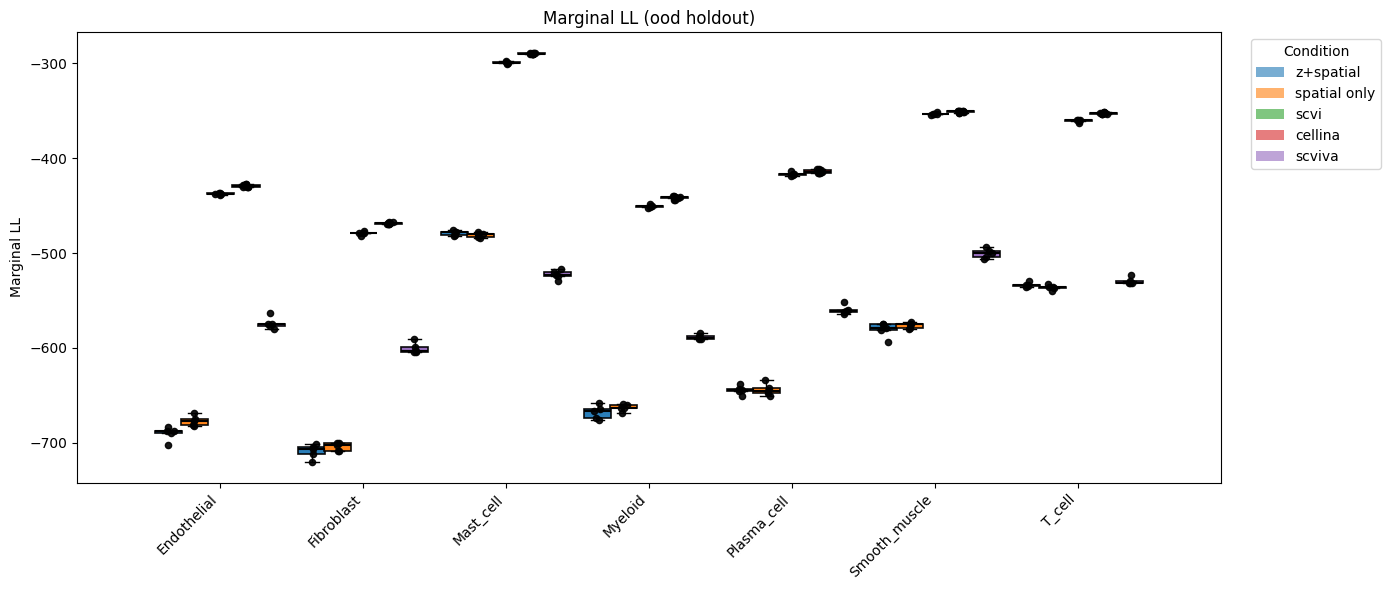

In [ ]:
def plot_mll_boxplot(results, title="Marginal LL on holdout (Higher is better)", conditions_order=None, celltypes=None, condition_name_map=None):
    """
    results: dict like {cond: {celltype: [mll_vals,...], ...}, ...}
    conditions_order: list to specify plotting order of conditions (optional)
    celltypes: list of celltypes to include (optional). Defaults to union across results.
    condition_name_map: dict mapping condition keys (bool or str) to display names, e.g. {True: "z+spatial", False: "spatial only"}
    """
    # default mapping (handles boolean and string keys)
    default_map = {True: "cellina_cond", False: "cellina", "True": "cellina_cond", "False": "cellina"}
    name_map = {**default_map, **(condition_name_map or {})}

    # determine conditions (preserve order if provided)
    conditions = conditions_order if conditions_order is not None else list(results.keys())
    n_cond = len(conditions)

    # determine celltypes (union across conditions) unless provided
    if celltypes is None:
        celltypes = sorted({ct for cond in conditions for ct in results.get(cond, {}).keys()})

    # filter out celltypes that have no data across all conditions
    filtered_celltypes = [ct for ct in celltypes if any(len(results.get(cond, {}).get(ct, [])) > 0 for cond in conditions)]
    if len(filtered_celltypes) == 0:
        filtered_celltypes = celltypes  # fallback if filter removed everything

    # positions for groups
    group_pos = np.arange(len(filtered_celltypes))
    box_width = 0.9 / max(1, n_cond)
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(n_cond)]

    fig, ax = plt.subplots(figsize=(14, 6))

    # For legend handles
    handles = []
    labels = []

    # Plot boxes per condition, aligning them inside each celltype group
    for j, cond in enumerate(conditions):
        data_to_plot = []
        pos_to_plot = []
        for i, ct in enumerate(filtered_celltypes):
            vals = results.get(cond, {}).get(ct, [])
            if len(vals) == 0:
                continue
            offset = (j - (n_cond - 1) / 2) * box_width
            data_to_plot.append(vals)
            pos_to_plot.append(group_pos[i] + offset)

        if len(data_to_plot) == 0:
            continue

        bp = ax.boxplot(
            data_to_plot,
            positions=pos_to_plot,
            widths=box_width * 1.05,
            patch_artist=True,
            manage_ticks=False,
            showfliers=False,
            boxprops={'linewidth': 1.2, 'edgecolor': 'black'},   # clearer edges
            medianprops={'color': 'black', 'linewidth': 2}
        )
        for patch in bp['boxes']:
            patch.set_facecolor(colors[j])
            patch.set_alpha(0.95)
        # median line style
        for median in bp['medians']:
            median.set(color='black', linewidth=1.5)

        # overlay jittered points per plotted box
        for k, p in enumerate(pos_to_plot):
            y = np.asarray(data_to_plot[k])
            x = np.random.normal(p, box_width * 0.08, size=len(y))
            ax.scatter(x, y, color='black', s=20, zorder=3, alpha=0.9)

        handles.append(plt.Rectangle((0,0),1,1, facecolor=colors[j], alpha=0.6))
        labels.append(name_map.get(cond, str(cond)))

    # finalize x-ticks and labels
    ax.set_xticks(group_pos)
    ax.set_xticklabels(filtered_celltypes, rotation=45, ha='right')
    ax.set_xlim(group_pos[0] - 1.0, group_pos[-1] + 1.0)
    ax.set_ylabel("Marginal LL")
    ax.set_title(title)
    ax.legend(handles, labels, title="Condition", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_mll_boxplot(results, title=f"Marginal LL ({split} holdout)")

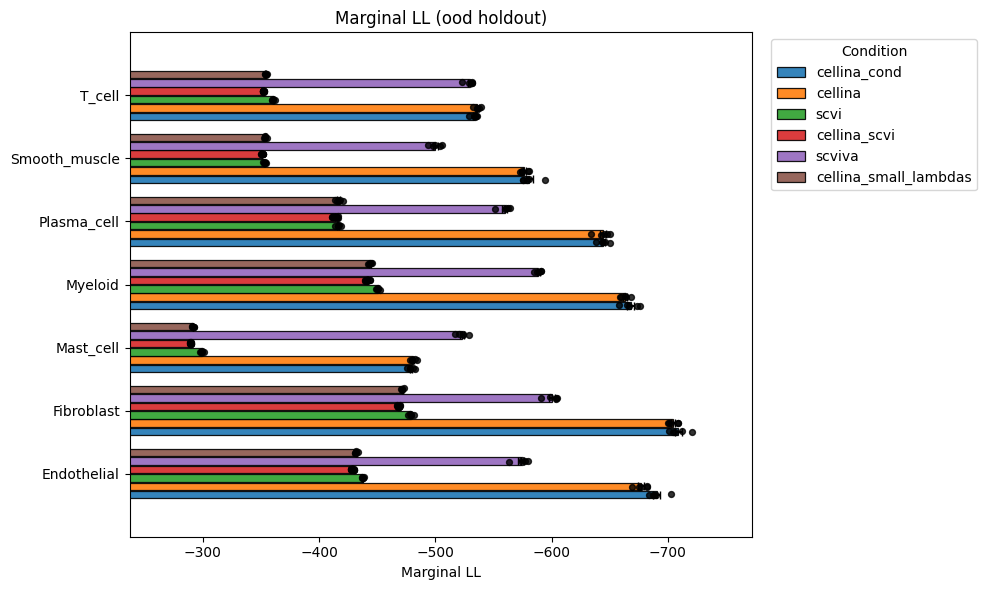

In [ ]:
# ...existing code...
def plot_mll_bar(results, title="Marginal LL on holdout (Higher is better)",
                 conditions_order=None, celltypes=None, condition_name_map=None,
                 error='sem'):
    """
    Horizontal bar plot of means per condition per celltype.

    results: dict like {cond: {celltype: [mll_vals,...], ...}, ...}
    conditions_order: optional list specifying condition plotting order
    celltypes: optional list of celltypes to include
    condition_name_map: dict mapping condition keys (bool or str) to display names
    error: 'sem' (default) or 'std' or None
    """
    # default mapping
    default_map = {True: "cellina_cond", False: "cellina",
                   "True": "cellina_cond", "False": "cellina",
                   }
    name_map = {**default_map, **(condition_name_map or {})}

    conditions = conditions_order if conditions_order is not None else list(results.keys())
    n_cond = len(conditions)

    if celltypes is None:
        # union of celltypes across conditions
        celltypes = sorted({ct for cond in conditions for ct in results.get(cond, {}).keys()})

    # keep only celltypes that have any data
    filtered_celltypes = [ct for ct in celltypes if any(len(results.get(cond, {}).get(ct, [])) > 0 for cond in conditions)]
    if len(filtered_celltypes) == 0:
        filtered_celltypes = celltypes

    cmap = plt.get_cmap("tab10")
    colors = [cmap(i) for i in range(n_cond)]

    group_pos = np.arange(len(filtered_celltypes))
    total_height = 0.8
    bar_height = total_height / max(1, n_cond)

    fig, ax = plt.subplots(figsize=(10, max(6, len(filtered_celltypes) * 0.35)))

    handles = []
    labels = []

    all_vals = []

    for j, cond in enumerate(conditions):
        means = []
        errs = []
        pos = []
        for i, ct in enumerate(filtered_celltypes):
            vals = np.asarray(results.get(cond, {}).get(ct, []))
            if len(vals) == 0:
                means.append(np.nan)
                errs.append(0.0)
            else:
                means.append(np.mean(vals))
                if error == 'sem':
                    errs.append(np.std(vals, ddof=0) / np.sqrt(len(vals)))
                elif error == 'std':
                    errs.append(np.std(vals, ddof=0))
                else:
                    errs.append(0.0)
                all_vals.extend(vals.tolist())
            offset = (j - (n_cond - 1) / 2) * bar_height
            pos.append(group_pos[i] + offset)

        means = np.array(means)
        errs = np.array(errs)
        pos = np.array(pos)

        # draw horizontal bars (skip NaN means)
        valid = ~np.isnan(means)
        bars = ax.barh(group_pos[valid] + (j - (n_cond - 1) / 2) * bar_height,
                       means[valid],
                       height=bar_height * 0.9,
                       color=colors[j],
                       alpha=0.9,
                       edgecolor='black',
                       linewidth=0.9,
                       xerr=errs[valid] if error is not None else None,
                       capsize=3)
        handles.append(bars[0])
        labels.append(name_map.get(cond, str(cond)))

        # overlay jittered points for each bar (points vary along x, jitter in y)
        for i_idx, p in enumerate(pos):
            ct = filtered_celltypes[i_idx]
            vals = np.asarray(results.get(cond, {}).get(ct, []))
            if len(vals) == 0:
                continue
            y = np.random.normal(p, bar_height * 0.06, size=len(vals))
            ax.scatter(vals, y, color='black', s=18, zorder=4, alpha=0.8)

    # tighten x-limits so bars are more horizontally visible
    if len(all_vals) > 0:
        xmin, xmax = np.min(all_vals), np.max(all_vals)
        rng = xmax - xmin
        pad = rng * 0.12 if rng > 0 else 1.0
        ax.set_xlim(xmin - pad, xmax + pad)
        ax.invert_xaxis()  # invert so higher values appear on the left and lower on the right

    ax.set_yticks(group_pos)
    ax.set_yticklabels(filtered_celltypes, rotation=0)
    ax.set_ylim(group_pos[0] - 1.0, group_pos[-1] + 1.0)
    ax.set_xlabel("Marginal LL")
    ax.set_title(title)
    ax.legend(handles, labels, title="Condition", bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
# ...existing code...

plot_mll_bar(results, title=f"Marginal LL ({split} holdout)")